# NB-GP Normative Modeling — cfRNA Application

GLM / Full VI NB-GP / Laplace NB-GP을 실제 cfRNA AnnData에 적용.  
HC 샘플로만 학습하고, 전체 샘플(HC + disease)에 대해 유전자별 Z-score를 산출한다.

| 항목 | 내용 |
|------|------|
| **X** | 10개 bias metric, StandardScaler (fit on HC) |
| **Y** | Raw counts (NB 모델이 직접 모델링) |
| **Z-score** | Pearson residual 또는 Randomized Quantile residual (Cell 8 상단에서 선택) |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import gpytorch
import scanpy as sc
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse
from scipy.stats import nbinom, norm
from scipy.special import gammaln
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

In [2]:
DATA_DIR  = Path("/project/cfRNA_NormativeModeling/OpenAccess_nfcore")
H5AD_PATH = DATA_DIR / "Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BIAS_COLUMNS = [
    "log(Total Reads)",
    "Spliced Reads (%)",
    "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction",
    "RNA Degradation (3' Bias)",
    "Platelet Score",
    "GC Bias",
    "Gene Length Bias",
    "NG80",
    "(NP80/NG80)",
]

print(f"Device   : {DEVICE}")
print(f"Data path: {H5AD_PATH}")

Device   : cuda
Data path: /project/cfRNA_NormativeModeling/OpenAccess_nfcore/Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad


In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata = adata[adata.obs["QC_Passed"] == True]
adata = adata[adata.obs["Phenotype_Processed"].notna()]
adata = adata[adata.obs["Phenotype_Processed"] != "Unknown"]

phenotypes = adata.obs["Phenotype_Processed"].astype(str).values
is_hc      = phenotypes == "Healthy Control"

# ── X: bias metric normalization (fit on HC only) ─────────────────
X_raw        = adata.obs[BIAS_COLUMNS].values.astype(np.float32)
scaler_X     = StandardScaler()
X_hc_scaled  = scaler_X.fit_transform(X_raw[is_hc])
X_all_scaled = scaler_X.transform(X_raw)

# ── Y: raw counts (rounded to nearest integer) ────────────────────
Y_raw = adata.X.toarray() if issparse(adata.X) else np.asarray(adata.X)
Y_raw = np.round(Y_raw).astype(np.float32)

# ── Protein-coding gene filter ────────────────────────────────────
is_pc          = (adata.var["GeneType"] == "protein_coding").values
pc_gene_names  = adata.var_names[is_pc].tolist()
pc_indices     = np.where(is_pc)[0]

# ── Disease group info ────────────────────────────────────────────
unique_diseases = sorted(set(phenotypes[~is_hc]) - {"nan", "Unknown", "None"})

print(f"Total samples  : {len(adata)}")
print(f"  HC           : {is_hc.sum()} | Disease: {(~is_hc).sum()}")
print(f"Protein-coding : {len(pc_gene_names)} genes")
print(f"X shape (HC)   : {X_hc_scaled.shape}")
print(f"Disease groups : {unique_diseases}")
print(f"Y_raw dtype    : {Y_raw.dtype}, sample values: {Y_raw[0, :5]}")

Total samples  : 3159
  HC           : 996 | Disease: 2163
Protein-coding : 20097 genes
X shape (HC)   : (996, 10)
Disease groups : ['AD', 'AML', 'CDCS', 'Colorectal Cancer', 'Diverticulitis', 'EPO_Treatment', 'Esophagus Cancer', 'GCSF_Donor', 'HIV', 'HIV + Tuberculosis', 'ICI-m ', 'ICI-treated Cancer', 'Liver Cancer', 'Liver Cirrhosis', 'Lung Cancer', 'ME/CFS', 'MGUS', 'MM', 'NAFLD', 'NASH', 'Other Cancer', 'Pancreatic Cancer', 'Pancreatic Cancer ', 'Pancreatitis', 'Pre-eclampsia', 'Stomach Cancer', 'Tuberculosis', 'Unspecified_Fibrosis']
Y_raw dtype    : float32, sample values: [ 0.  0.  0. 26. 35.]


## Model Definitions

In [4]:
# =====================================================================
# GLM: statsmodels NegativeBinomialP(p=1)
# =====================================================================
class NBGLM:
    """NB GLM wrapper. Falls back to intercept-only model on convergence failure."""

    def __init__(self):
        self._result    = None
        self._mu_fb     = None  # fallback mean
        self.theta_     = None

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        X_c = sm.add_constant(X_train, has_constant="add")
        try:
            res = sm.NegativeBinomialP(y_train, X_c, p=1).fit(disp=False, maxiter=100)
            self._result = res
            self.theta_  = max(0.1, 1.0 / (abs(float(res.params[-1])) + 1e-6))
        except Exception:
            self._result = None
            self._mu_fb  = float(y_train.mean()) if len(y_train) > 0 else 1.0
            self.theta_  = 1.0
        return self

    def predict(self, X_test: np.ndarray):
        """Returns (mu_pred: ndarray, theta: float)."""
        X_c = sm.add_constant(X_test, has_constant="add")
        if self._result is not None:
            mu = self._result.predict(X_c).astype(np.float32)
        else:
            mu = np.full(len(X_test), self._mu_fb, dtype=np.float32)
        return np.clip(mu, 1e-4, 1e6), self.theta_

In [5]:
# =====================================================================
# Full Variational Inference NB-GP
# =====================================================================
class VINGBLikelihood(gpytorch.likelihoods.Likelihood):
    def __init__(self):
        super().__init__()
        self.raw_theta = nn.Parameter(torch.tensor(0.0))

    @property
    def theta(self):
        return nn.functional.softplus(self.raw_theta) + 1e-4

    def forward(self, function_samples, **kwargs):
        # f = log(mu)  →  logits = f - log(theta)
        logits = function_samples - torch.log(self.theta)
        return torch.distributions.NegativeBinomial(total_count=self.theta, logits=logits)


class VINBGP(gpytorch.models.ApproximateGP):
    def __init__(self, X_train):
        var_dist  = gpytorch.variational.CholeskyVariationalDistribution(X_train.size(0))
        var_strat = gpytorch.variational.VariationalStrategy(
            self, X_train, var_dist, learn_inducing_locations=False
        )
        super().__init__(var_strat)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=X_train.size(-1))
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x)
        )


def train_vi_nbgp(X_train, y_train, max_epochs=300, lr=0.05):
    """Returns (model, likelihood) in eval mode. Respects X_train.device."""
    dev        = X_train.device
    model      = VINBGP(X_train).to(dev)
    likelihood = VINGBLikelihood().to(dev)
    model.train(); likelihood.train()

    opt = torch.optim.Adam(
        [{"params": model.parameters()}, {"params": likelihood.parameters()}],
        lr=lr,
    )
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.size(0))

    for _ in range(max_epochs):
        opt.zero_grad()
        loss = -mll(model(X_train), y_train)
        loss.backward()
        opt.step()

    model.eval(); likelihood.eval()
    return model, likelihood

In [6]:
# =====================================================================
# Laplace Approximation NB-GP
# =====================================================================
class LaplaceNBGP(nn.Module):
    def __init__(self, n_features, theta_init=2.0):
        super().__init__()
        self.log_output_scale = nn.Parameter(torch.zeros(1))
        self.log_length_scale = nn.Parameter(torch.zeros(n_features))
        self.raw_theta = nn.Parameter(
            torch.tensor(float(np.log(np.exp(theta_init) - 1.0 + 1e-6)))
        )

    @property
    def theta(self):
        return nn.functional.softplus(self.raw_theta) + 0.1

    def kernel(self, X1, X2=None):
        if X2 is None:
            X2 = X1
        ls   = self.log_length_scale.exp()
        os   = self.log_output_scale.exp()
        diff = (X1.unsqueeze(1) - X2.unsqueeze(0)) / ls
        return os * (-0.5 * diff.pow(2).sum(-1)).exp()

    @staticmethod
    def _nb_grad_W(f, y, theta):
        mu   = f.exp().clamp(1e-4, 1e4)
        grad = y - mu * (y + theta) / (mu + theta)
        W    = (mu * theta * (y + theta) / (mu + theta).pow(2)).clamp(1e-8)
        return grad, W

    def _safe_cholesky(self, A):
        dev = A.device
        for jitter in [1e-4, 1e-3, 1e-2, 1e-1]:
            try:
                return torch.linalg.cholesky(A + jitter * torch.eye(len(A), device=dev))
            except Exception:
                continue
        raise RuntimeError("Cholesky failed after jitter escalation")

    def find_map(self, K, y, f0=None, max_iter=50, tol=1e-5):
        n, theta = len(y), self.theta.detach()
        dev = K.device
        f = f0.detach().clone() if f0 is not None else torch.zeros(n, device=dev)
        with torch.no_grad():
            for _ in range(max_iter):
                grad, W  = self._nb_grad_W(f, y, theta)
                sqrt_W   = W.sqrt()
                B        = torch.eye(n, device=dev) + sqrt_W[:, None] * K * sqrt_W[None, :]
                try:
                    L = self._safe_cholesky(B)
                except RuntimeError:
                    break
                b     = W * f + grad
                v     = torch.cholesky_solve((sqrt_W * (K @ b))[:, None], L).squeeze()
                f_new = K @ (b - sqrt_W * v)
                if (f_new - f).norm().item() < tol:
                    return f_new
                f = f_new
        return f

    def log_marginal_lik(self, K, f_map, y):
        theta, f = self.theta, f_map.detach()
        dev      = K.device
        _, W     = self._nb_grad_W(f, y, theta)
        sqrt_W   = W.clamp(1e-8).sqrt()
        B        = torch.eye(len(y), device=dev) + sqrt_W[:, None] * K * sqrt_W[None, :]
        try:
            L = self._safe_cholesky(B)
        except RuntimeError:
            return K.sum() * 0.0 - 1e8

        mu      = f.exp().clamp(1e-4, 1e4)
        log_lik = (
            torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1)
            + theta * (theta.log() - (theta + mu).log())
            + y    * (mu.log()    - (theta + mu).log())
        ).sum()
        K_chol    = self._safe_cholesky(K)
        alpha     = torch.cholesky_solve(f[:, None], K_chol).squeeze()
        log_prior = -0.5 * (f * alpha).sum()
        log_det   = -L.diagonal().log().sum()
        return log_lik + log_prior + log_det

    def posterior_predictive(self, K_train, f_map, y, K_cross, k_test_diag):
        theta, f = self.theta.detach(), f_map.detach()
        dev      = K_train.device
        grad, W  = self._nb_grad_W(f, y, theta)
        sqrt_W   = W.sqrt()
        B        = torch.eye(len(y), device=dev) + sqrt_W[:, None] * K_train * sqrt_W[None, :]
        try:
            L = self._safe_cholesky(B)
        except RuntimeError:
            return torch.zeros(k_test_diag.shape, device=dev), k_test_diag

        f_mean = K_cross.T @ grad
        v      = torch.linalg.solve_triangular(L, sqrt_W[:, None] * K_cross, upper=False)
        f_var  = (k_test_diag - v.pow(2).sum(0)).clamp(0)
        return f_mean, f_var


def train_laplace_nbgp(X_train, y_train, max_epochs=200, lr=0.01):
    """Returns (model, f_map) in eval mode. Respects X_train.device."""
    dev   = X_train.device
    model = LaplaceNBGP(X_train.shape[-1]).to(dev)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    f_map = torch.zeros(len(y_train), device=dev)

    for _ in range(max_epochs):
        model.eval()
        with torch.no_grad():
            f_map = model.find_map(model.kernel(X_train), y_train, f0=f_map)
        model.train()
        opt.zero_grad()
        try:
            loss = -model.log_marginal_lik(model.kernel(X_train), f_map, y_train)
        except Exception:
            continue
        if torch.isnan(loss):
            continue
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        f_map = model.find_map(model.kernel(X_train), y_train, f0=f_map)
    return model, f_map.detach()

## Z-score Functions

두 가지 방식을 모두 제공하며, `ZSCORE_METHOD` 변수로 선택한다.

| 방식 | 공식 | 특성 |
|------|------|------|
| `"pearson"` | $(y - \mu) / \sqrt{\mu + \mu^2/\theta}$ | 재현 가능, 점근적 N(0,1) |
| `"quantile"` | $\Phi^{-1}(U[F(y-1), F(y)])$ | 엄밀히 N(0,1), stochastic |

In [7]:
def pearson_zscore(y: np.ndarray, mu: np.ndarray, theta: float) -> np.ndarray:
    """Pearson residual under NB(mu, theta). Asymptotically N(0,1). Reproducible."""
    var = mu + mu ** 2 / max(theta, 1e-6)
    return (y - mu) / np.sqrt(var + 1e-8)


def quantile_zscore(
    y: np.ndarray, mu: np.ndarray, theta: float, seed: int | None = None
) -> np.ndarray:
    """Randomized quantile residual (Dunn & Smyth 1996).
    Exactly N(0,1) under the correct NB model.
    Stochastic — pass seed for reproducibility within a run.

    scipy nbinom(n, p) parameterization: p = theta / (theta + mu)
    """
    theta = max(theta, 1e-4)
    p     = np.clip(theta / (theta + mu + 1e-8), 1e-8, 1 - 1e-8)
    y_int = y.astype(int)

    # CDF at y-1: for y=0, CDF(-1) = 0 by convention
    a = np.where(y_int > 0, nbinom.cdf(y_int - 1, n=theta, p=p), 0.0)
    b = nbinom.cdf(y_int, n=theta, p=p)

    rng = np.random.default_rng(seed)
    u   = rng.uniform(
        np.clip(a, 1e-8, 1 - 1e-8),
        np.clip(b, 1e-8, 1 - 1e-8),
    )
    return norm.ppf(u)


def compute_zscore(
    y: np.ndarray,
    mu: np.ndarray,
    theta: float,
    method: str = "pearson",
    seed: int | None = None,
) -> np.ndarray:
    """method: 'pearson' | 'quantile'"""
    y, mu = np.asarray(y, dtype=np.float32), np.asarray(mu, dtype=np.float32)
    if method == "pearson":
        return pearson_zscore(y, mu, theta)
    if method == "quantile":
        return quantile_zscore(y, mu, theta, seed=seed)
    raise ValueError(f"Unknown method: {method!r}. Choose 'pearson' or 'quantile'.")


# ── Per-model scoring helpers ─────────────────────────────────────

def score_glm(
    glm: NBGLM, X_all: np.ndarray, y_all: np.ndarray,
    method: str = "pearson", seed: int | None = None,
):
    """Returns (z, mu_pred, theta)."""
    mu, theta = glm.predict(X_all)
    return compute_zscore(y_all, mu, theta, method=method, seed=seed), mu, theta


def score_vi(
    vi_model: VINBGP, vi_lik: VINGBLikelihood,
    X_all_t: torch.Tensor, y_all: np.ndarray,
    method: str = "pearson", n_samples: int = 300, seed: int | None = None,
):
    """Returns (z, mu_pred, theta). mu_pred estimated via MC sampling from posterior."""
    with torch.no_grad():
        f_samples = vi_model(X_all_t).rsample(torch.Size([n_samples]))  # (S, N)
    mu    = f_samples.exp().mean(0).cpu().numpy()
    theta = vi_lik.theta.item()
    return compute_zscore(y_all, mu, theta, method=method, seed=seed), mu, theta


def score_laplace(
    lap_model: LaplaceNBGP, f_map: torch.Tensor,
    X_tr_t: torch.Tensor, y_tr_t: torch.Tensor,
    X_all_t: torch.Tensor, y_all: np.ndarray,
    method: str = "pearson", n_samples: int = 300, seed: int | None = None,
):
    """Returns (z, mu_pred, theta). mu_pred estimated via Laplace posterior MC."""
    with torch.no_grad():
        K_tr    = lap_model.kernel(X_tr_t)
        K_cross = lap_model.kernel(X_tr_t, X_all_t)
        k_diag  = lap_model.kernel(X_all_t).diagonal()
        f_mean, f_var = lap_model.posterior_predictive(K_tr, f_map, y_tr_t, K_cross, k_diag)
    f_samples = torch.distributions.Normal(
        f_mean, f_var.sqrt().clamp(1e-6)
    ).rsample(torch.Size([n_samples]))
    mu    = f_samples.exp().mean(0).cpu().numpy()
    theta = lap_model.theta.item()
    return compute_zscore(y_all, mu, theta, method=method, seed=seed), mu, theta

## Gene-by-Gene Pipeline

`ZSCORE_METHOD` 와 `N_GENES_TEST` 를 조정하여 실행 범위를 제어한다.

In [11]:
# ── Run Configuration ────────────────────────────────────────────
ZSCORE_METHOD = "pearson"   # "pearson" | "quantile"
N_GENES_TEST  = 50         # None → all ~20k protein-coding genes
RANDOM_SEED   = 42
VI_EPOCHS     = 300
LAP_EPOCHS    = 200
MC_SAMPLES    = 300

target_names   = pc_gene_names[:N_GENES_TEST] if N_GENES_TEST else pc_gene_names
target_indices = pc_indices[:N_GENES_TEST]    if N_GENES_TEST else pc_indices
N_all          = len(adata)

print(f"Z-score method : {ZSCORE_METHOD}")
print(f"Device         : {DEVICE}")
print(f"Target genes   : {len(target_names)}")
print(f"HC samples     : {is_hc.sum()} | All samples: {N_all}")

# ── Storage ──────────────────────────────────────────────────────
z_glm_all = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)
z_vi_all  = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)
z_lap_all = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)
gene_meta = []

X_tr_t  = torch.tensor(X_hc_scaled,  dtype=torch.float32).to(DEVICE)
X_all_t = torch.tensor(X_all_scaled, dtype=torch.float32).to(DEVICE)

# ── Gene loop ────────────────────────────────────────────────────
for i, (g_name, g_idx) in enumerate(zip(target_names, target_indices)):
    y_hc  = Y_raw[is_hc,  g_idx]
    y_all = Y_raw[:, g_idx]
    y_tr_t = torch.tensor(y_hc, dtype=torch.float32).to(DEVICE)

    det_rate_hc   = float((y_hc > 0).mean())
    hc_mean_count = float(y_hc.mean())

    meta = {
        "gene": g_name,
        "det_rate_hc": det_rate_hc,
        "hc_mean_count": hc_mean_count,
    }

    # 1. GLM
    glm = NBGLM().fit(X_hc_scaled, y_hc)
    z_glm, _, th_glm = score_glm(
        glm, X_all_scaled, y_all, method=ZSCORE_METHOD, seed=RANDOM_SEED
    )
    z_glm_all[:, i] = z_glm
    meta["theta_glm"] = th_glm

    # 2. Full VI NB-GP
    vi_model, vi_lik = train_vi_nbgp(X_tr_t, y_tr_t, max_epochs=VI_EPOCHS)
    z_vi, _, th_vi = score_vi(
        vi_model, vi_lik, X_all_t, y_all,
        method=ZSCORE_METHOD, n_samples=MC_SAMPLES, seed=RANDOM_SEED,
    )
    z_vi_all[:, i] = z_vi
    meta["theta_vi"] = th_vi
    del vi_model, vi_lik

    # 3. Laplace NB-GP
    lap_model, f_map = train_laplace_nbgp(X_tr_t, y_tr_t, max_epochs=LAP_EPOCHS)
    z_lap, _, th_lap = score_laplace(
        lap_model, f_map, X_tr_t, y_tr_t, X_all_t, y_all,
        method=ZSCORE_METHOD, n_samples=MC_SAMPLES, seed=RANDOM_SEED,
    )
    z_lap_all[:, i] = z_lap
    meta["theta_lap"] = th_lap
    del lap_model, f_map

    gene_meta.append(meta)

    if (i + 1) % 50 == 0 or i == 0:
        print(
            f"[{i+1:4d}/{len(target_names)}] {g_name:<20s} "
            f"det={det_rate_hc:.2f}  "
            f"θ_glm={th_glm:.2f}  θ_vi={th_vi:.2f}  θ_lap={th_lap:.2f}"
        )

df_meta = pd.DataFrame(gene_meta)
print(f"\nDone. Z-score matrices: {z_glm_all.shape}")

Z-score method : pearson
Device         : cuda
Target genes   : 50
HC samples     : 996 | All samples: 3159
[   1/50] ENSG00000000003.17   det=0.56  θ_glm=0.10  θ_vi=0.33  θ_lap=1.10
[  50/50] ENSG00000004468.14   det=0.84  θ_glm=0.10  θ_vi=0.64  θ_lap=0.92

Done. Z-score matrices: (3159, 50)


## QC Metrics & Gene Filtering

HC 샘플의 Z-score 분포를 기준으로 유효 유전자를 선별한다.

In [12]:
def compute_hc_qc(
    z_matrix: np.ndarray, is_hc: np.ndarray, gene_names: list
) -> pd.DataFrame:
    """Z-score QC on HC samples per gene."""
    z_hc   = z_matrix[is_hc]
    z_mean = np.nanmean(z_hc, axis=0)
    z_std  = np.nanstd(z_hc,  axis=0)
    return pd.DataFrame({"gene": gene_names, "Z_Mean": z_mean, "Z_Std": z_std})


def filter_valid_genes(
    df_meta: pd.DataFrame,
    df_qc: pd.DataFrame,
    det_rate_th: float = 0.1,
    mean_count_th: float = 2.0,
    z_mean_th: float = 0.2,
    z_std_min: float = 0.4,
    z_std_max: float = 1.4,
) -> pd.DataFrame:
    df = df_meta.merge(df_qc, on="gene")

    m_det   = df["det_rate_hc"]  >= det_rate_th
    m_count = df["hc_mean_count"] >= mean_count_th
    m_zmean = df["Z_Mean"].abs() <= z_mean_th
    m_zstd  = (df["Z_Std"] >= z_std_min) & (df["Z_Std"] <= z_std_max)

    df["valid"]       = m_det & m_count & m_zmean & m_zstd
    df["fail_reason"] = ""
    df.loc[~m_det,                  "fail_reason"] += "Low_DetRate "
    df.loc[~m_count,                "fail_reason"] += "Low_Count "
    df.loc[~m_zmean,                "fail_reason"] += "Biased_Mean "
    df.loc[df["Z_Std"] < z_std_min, "fail_reason"] += "Low_Std(Overfit) "
    df.loc[df["Z_Std"] > z_std_max, "fail_reason"] += "High_Std(Underfit) "
    df["fail_reason"] = df["fail_reason"].str.strip()
    return df


# ── Compute QC ────────────────────────────────────────────────────
qc_glm = compute_hc_qc(z_glm_all, is_hc, target_names)
qc_vi  = compute_hc_qc(z_vi_all,  is_hc, target_names)
qc_lap = compute_hc_qc(z_lap_all, is_hc, target_names)

df_filter_glm = filter_valid_genes(df_meta, qc_glm)
df_filter_vi  = filter_valid_genes(df_meta, qc_vi)
df_filter_lap = filter_valid_genes(df_meta, qc_lap)

for method_name, df_f in [("GLM", df_filter_glm), ("VI", df_filter_vi), ("Laplace", df_filter_lap)]:
    n_valid = df_f["valid"].sum()
    print(f"{method_name:7s} — valid: {n_valid}/{len(df_f)} ({n_valid/len(df_f)*100:.1f}%)")
    reason_counts = (
        df_f.loc[~df_f["valid"] & df_f["fail_reason"].ne(""), "fail_reason"]
        .value_counts().head(5)
    )
    print(reason_counts.to_string())
    print()

GLM     — valid: 18/50 (36.0%)
fail_reason
Low_Std(Overfit)                26
High_Std(Underfit)               3
Low_Count High_Std(Underfit)     3

VI      — valid: 47/50 (94.0%)
fail_reason
Low_Count    3

Laplace — valid: 10/50 (20.0%)
fail_reason
Biased_Mean                       18
Biased_Mean High_Std(Underfit)    18
Low_Count Biased_Mean              3
Biased_Mean Low_Std(Overfit)       1



## Results & Visualization

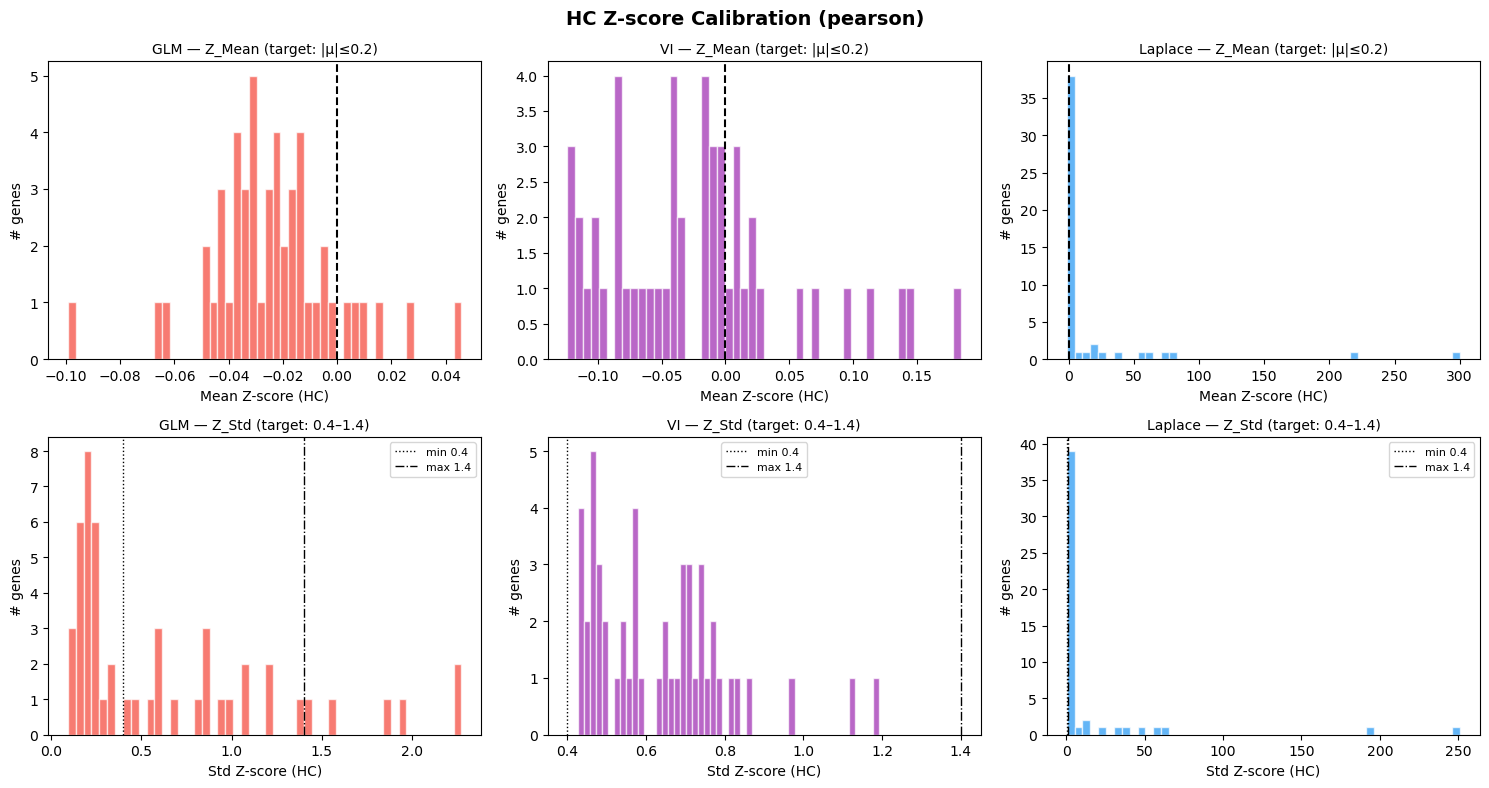

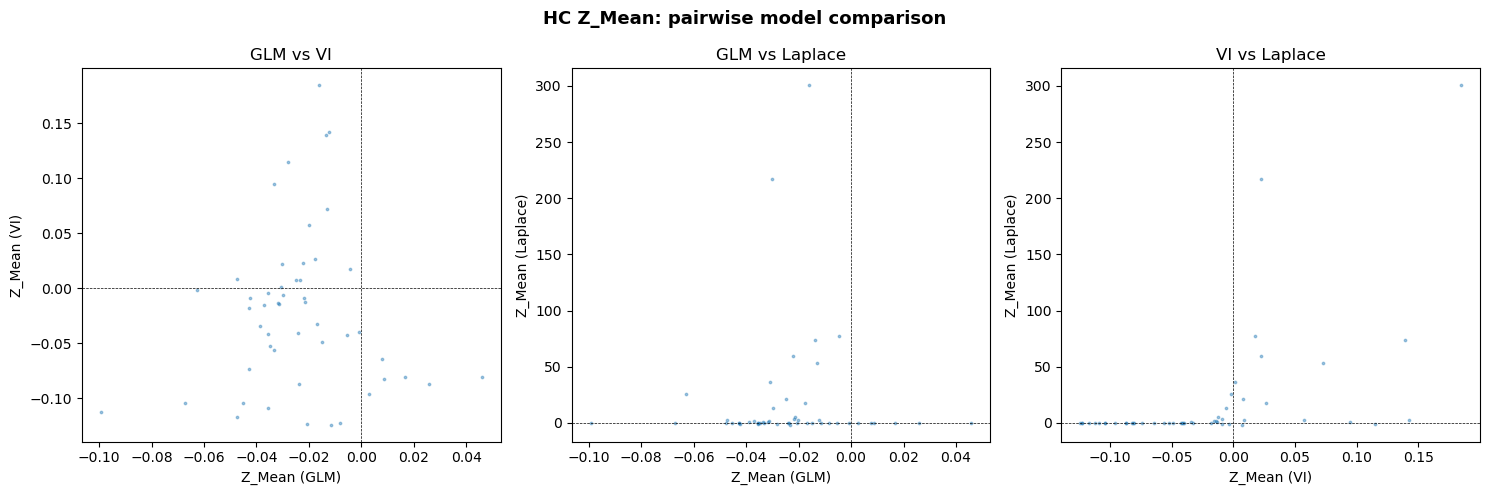

In [13]:
# ── 1. HC Z-score calibration: Z_Mean & Z_Std distributions ──────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.suptitle(f"HC Z-score Calibration ({ZSCORE_METHOD})", fontsize=14, fontweight="bold")

method_configs = [
    ("GLM",     qc_glm, "#F44336"),
    ("VI",      qc_vi,  "#9C27B0"),
    ("Laplace", qc_lap, "#2196F3"),
]

for col, (m_name, qc_df, color) in enumerate(method_configs):
    ax = axes[0, col]
    ax.hist(qc_df["Z_Mean"].dropna(), bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(f"{m_name} — Z_Mean (target: |μ|≤0.2)", fontsize=10)
    ax.set_xlabel("Mean Z-score (HC)"); ax.set_ylabel("# genes")

    ax = axes[1, col]
    ax.hist(qc_df["Z_Std"].dropna(), bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0.4, color="k", lw=1, ls=":", label="min 0.4")
    ax.axvline(1.4, color="k", lw=1, ls="-.", label="max 1.4")
    ax.set_title(f"{m_name} — Z_Std (target: 0.4–1.4)", fontsize=10)
    ax.set_xlabel("Std Z-score (HC)"); ax.set_ylabel("# genes")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 2. Model comparison: Z_Mean scatter ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("HC Z_Mean: pairwise model comparison", fontsize=13, fontweight="bold")

pairs = [("GLM", qc_glm), ("VI", qc_vi), ("Laplace", qc_lap)]
pair_combos = [(pairs[0], pairs[1]), (pairs[0], pairs[2]), (pairs[1], pairs[2])]

for ax, (pair1, pair2) in zip(axes, pair_combos):
    n1, df1 = pair1
    n2, df2 = pair2
    merged = df1.merge(df2, on="gene", suffixes=(f"_{n1}", f"_{n2}"))
    ax.scatter(merged[f"Z_Mean_{n1}"], merged[f"Z_Mean_{n2}"], s=3, alpha=0.4)
    ax.axhline(0, color="k", lw=0.5, ls="--"); ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.set_xlabel(f"Z_Mean ({n1})"); ax.set_ylabel(f"Z_Mean ({n2})")
    ax.set_title(f"{n1} vs {n2}")

plt.tight_layout()
plt.show()

In [14]:
# ── Save Z-score matrices & QC tables ────────────────────────────
sample_ids = adata.obs_names.tolist()
OUT_DIR    = Path("/project/cfRNA_NormativeModeling/results_nb_gp")
OUT_DIR.mkdir(exist_ok=True)

tag = f"{ZSCORE_METHOD}_n{len(target_names)}"

pd.DataFrame(z_glm_all, index=sample_ids, columns=target_names).to_csv(
    OUT_DIR / f"zscores_glm_{tag}.csv"
)
pd.DataFrame(z_vi_all,  index=sample_ids, columns=target_names).to_csv(
    OUT_DIR / f"zscores_vi_{tag}.csv"
)
pd.DataFrame(z_lap_all, index=sample_ids, columns=target_names).to_csv(
    OUT_DIR / f"zscores_laplace_{tag}.csv"
)

df_filter_glm.to_csv(OUT_DIR / f"qc_glm_{tag}.csv",     index=False)
df_filter_vi.to_csv( OUT_DIR / f"qc_vi_{tag}.csv",      index=False)
df_filter_lap.to_csv(OUT_DIR / f"qc_laplace_{tag}.csv", index=False)

print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")

Saved to: /project/cfRNA_NormativeModeling/results_nb_gp
  qc_glm_pearson_n50.csv
  qc_laplace_pearson_n50.csv
  qc_vi_pearson_n50.csv
  zscores_glm_pearson_n50.csv
  zscores_laplace_pearson_n50.csv
  zscores_vi_pearson_n50.csv
